In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import itertools
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# MLPClassifier

The MLPClassifier contains several functions that are used for training, testing, and evaluation. It is made up of three MLP models, as well as the fit, predict, evaluate, and grid_search_MLP functions.


## Model Architecture (3 MLP models)

The class contains three MLP models: small (3 layers), medium (4 layers), and large (5 layers). All the models are very similar to each other. The small model is the medium model with the first layer removed, and the medium model is the large model with the first layer removed. Each model consists of a sequence of linear layers with ReLU activation functions. The models also include batch normalization and dropout (0.4) in each layer except the last two layers. Batch normalization is included to stabilize training, and dropout is used to reduce overfitting. The final layer produces outputs equal to the number of classes. This design structure allows us to test different MLP models with varying numbers of layers.

- Small MLP:
Flatten input_dim → Linear(input_dim→128) → ReLU → BatchNorm1d(128) → Dropout(0.4) → Linear(128→64) → ReLU → Linear(64→num_classes).

- Medium MLP:
Flatten input_dim → Linear(input_dim→256) → ReLU → BatchNorm1d(256) → Dropout(0.4) → Linear(256→128) → ReLU → BatchNorm1d(128) → Dropout(0.4) → Linear(128→64) → ReLU → Linear(64→num_classes).

- Large MLP:
Flatten input_dim → Linear(input_dim→512) → ReLU → BatchNorm1d(512) → Dropout(0.4) → Linear(512→256) → ReLU → BatchNorm1d(256) → Dropout(0.4) → Linear(256→128) → ReLU → BatchNorm1d(128) → Dropout(0.4) → Linear(128→64) → ReLU → Linear(64→num_classes).

## Fit Function

The fit function handles all the training. Models were trained using the Adam optimizer with weight decay for regularization. The loss function used was Cross-Entropy Loss with label smoothing, which helps improve generalization.

Training was performed in mini-batches using PyTorch. During each epoch, the model was first trained on the training set, and then its performance was evaluated on the validation set. Validation accuracy was used as the main metric for model selection.

To ensure that the best-performing model was preserved, the weights corresponding to the highest validation accuracy were saved during training and reloaded at the end.

## Predict Function

Produces the outputs and selects the prediction with the highest probability.



## Evaluate Function

Uses the true values and predicted values to evaluate accuracy.

## Grid_search_mlp Function

It performs hyperparameter tuning. It receives all the parameters for training and returns the best model among all the models.

## Seed_seed Function

Sets the random seed to fixed numbers.

## Run_across_seeds Function

It performs test runs under different random seeds. The selected seed number is used to train and evaluate the model. It returns the first example of true and predicted values, as well as the average metric results and their standard deviation.

In [2]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, size="small"):
        super().__init__()

        if size == "small":
            layers = [
                nn.Linear(input_dim, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.Dropout(0.4),

                nn.Linear(128, 64),
                nn.ReLU(),

                nn.Linear(64, num_classes)
            ]

        elif size == "medium":
            layers = [
                nn.Linear(input_dim, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(0.4),

                nn.Linear(256, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.Dropout(0.4),

                nn.Linear(128, 64),
                nn.ReLU(),

                nn.Linear(64, num_classes)
            ]

        elif size == "large":
            layers = [
                nn.Linear(input_dim, 512),
                nn.ReLU(),
                nn.BatchNorm1d(512),
                nn.Dropout(0.4),

                nn.Linear(512, 256),
                nn.ReLU(),
                nn.BatchNorm1d(256),
                nn.Dropout(0.4),

                nn.Linear(256, 128),
                nn.ReLU(),
                nn.BatchNorm1d(128),
                nn.Dropout(0.4),

                nn.Linear(128, 64),
                nn.ReLU(),

                nn.Linear(64, num_classes)
            ]
        else:
            raise ValueError("size must be 'small', 'medium' or 'large'")

        self.net = nn.Sequential(*layers)
        self.best_model_state = None
        self.best_val_acc = 0.0

    def forward(self, x):
        return self.net(x)

    def fit(self, X_train_t, y_train_t, X_val_t, y_val_t, lr=5e-4, batch_size=64, epochs=30):
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=5e-4)

        train_loader = DataLoader(
            TensorDataset(X_train_t, y_train_t),
            batch_size=batch_size,
            shuffle=True
        )
        val_loader = DataLoader(
            TensorDataset(X_val_t, y_val_t),
            batch_size=batch_size,
            shuffle=False
        )

        self.best_val_acc = 0.0
        self.best_model_state = None
        self.history = {"train_loss": [], "train_acc": [], "val_acc": []}

        for epoch in range(epochs):
            # Train
            self.train()
            train_correct = 0
            train_total = 0
            running_loss = 0.0

            for xb, yb in train_loader:
                optimizer.zero_grad()
                outputs = self(xb)
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                train_correct += (preds == yb).sum().item()
                train_total += yb.size(0)

            train_acc = train_correct / train_total
            train_loss_mean = running_loss / len(train_loader)

            # Validation
            self.eval()
            val_preds = []
            val_true = []

            with torch.no_grad():
                for xb, yb in val_loader:
                    outputs = self(xb)
                    preds = torch.argmax(outputs, dim=1)

                    val_preds.extend(preds.cpu().numpy())
                    val_true.extend(yb.cpu().numpy())

            val_acc = accuracy_score(val_true, val_preds)

            self.history["train_loss"].append(train_loss_mean)
            self.history["train_acc"].append(train_acc)
            self.history["val_acc"].append(val_acc)

            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.best_model_state = copy.deepcopy(self.state_dict())

        # load best model after training
        if self.best_model_state is not None:
            self.load_state_dict(self.best_model_state)

        return self.best_val_acc

    def predict(self, X_test_t):
        self.eval()
        with torch.no_grad():
            outputs = self(X_test_t)
            preds = torch.argmax(outputs, dim=1)
        return preds.cpu().numpy()

    def evaluate(self, X_test_t, y_test_t):
        y_pred = self.predict(X_test_t)
        y_true = y_test_t.cpu().numpy()
        acc = accuracy_score(y_true, y_pred)
        return y_pred, y_true, acc

    def plot_learning_curves(self):
        """Plot train loss and train/val accuracy vs epoch from the last fit()."""
        h = self.history
        if not h or not h.get("train_loss"):
            raise ValueError("No training history; call fit() first.")
        epoch_idx = np.arange(1, len(h["train_loss"]) + 1)
        fig, (ax_loss, ax_acc) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
        ax_loss.plot(epoch_idx, h["train_loss"])
        ax_loss.set_ylabel("Train loss")
        ax_loss.set_title("Learning curves")
        ax_loss.grid(True, alpha=0.3)
        ax_acc.plot(epoch_idx, h["train_acc"], label="Train acc")
        ax_acc.plot(epoch_idx, h["val_acc"], label="Val acc")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.legend()
        ax_acc.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def grid_search_mlp(X_train_t, y_train_t, X_val_t, y_val_t, input_dim, num_classes, param_grid):
        keys = list(param_grid.keys())
        values = list(param_grid.values())

        best_score = -1
        best_params = None
        best_model = None
        results = []

        for combination in itertools.product(*values):
            params = dict(zip(keys, combination))

            model = MLPClassifier(
                input_dim=input_dim,
                num_classes=num_classes,
                size=params["size"]
            )

            val_acc = model.fit(
                X_train_t, y_train_t,
                X_val_t, y_val_t,
                lr=params["lr"],
                batch_size=params["batch_size"],
                epochs=params["epochs"]
            )

            results.append({
                "params": params,
                "val_acc": val_acc
            })

            if val_acc > best_score:
                best_score = val_acc
                best_params = params
                best_model = model

        return best_model, best_params, best_score, results
    

    @staticmethod
    def set_seed(seed: int):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
    
    @staticmethod
    def run_across_seeds(
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        input_dim,
        num_classes,
        param_grid,
        n_seeds=5,
        random_state=42,
    ):
        
        
        random.seed(random_state)
        seeds = [random.randint(1, 10000) for _ in range(n_seeds)]

        all_results = []
        best_models = []
        cms = []

        y_true_example = None
        y_pred_example = None
        seed_example = None
        
        for trial, seed in enumerate(seeds):
            MLPClassifier.set_seed(seed)
            print(f"\nRunning seed {trial + 1}/{n_seeds} | seed={seed}")

            best_model, best_params, best_score, grid_results = MLPClassifier.grid_search_mlp(
                X_train,
                y_train,
                X_val,
                y_val,
                input_dim=input_dim,
                num_classes=num_classes,
                param_grid=param_grid,
            )

            final_model = MLPClassifier(
                input_dim=input_dim,
                num_classes=num_classes,
                size=best_params["size"]
            )

            final_model_best_score =final_model.fit(
                X_train,
                y_train,
                X_val,
                y_val,
                lr=best_params["lr"],
                batch_size=best_params["batch_size"],
                epochs=30
            )

            print("Best Params:", best_params)
            print("Best Validation Accuracy:", best_score)

            y_pred, y_true, test_acc = final_model.evaluate(X_test, y_test)

            cm = confusion_matrix(y_true, y_pred)
            cms.append(cm)

            if trial == 0:
                y_true_example = y_true
                y_pred_example = y_pred
                seed_example = seed

            result = {
                "seed": seed,
                "val_acc": best_score,
                "test_acc": test_acc,
                "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
                "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
                "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
                "best_params": best_params,
            }

            all_results.append(result)
            best_models.append(final_model)

            print(
                f"Seed {seed} done | "
                f"test_acc={result['test_acc']:.4f}, "
                f"precision={result['precision']:.4f}, "
                f"recall={result['recall']:.4f}, "
                f"f1={result['f1']:.4f}"
            )

        results_df = pd.DataFrame([
            {
                "seed": r["seed"],
                "val_acc": r["val_acc"],
                "test_acc": r["test_acc"],
                "precision": r["precision"],
                "recall": r["recall"],
                "f1": r["f1"],
            }
            for r in all_results
        ])

        avg_metrics = results_df[["val_acc", "test_acc", "precision", "recall", "f1"]].mean()
        std_metrics = results_df[["val_acc", "test_acc", "precision", "recall", "f1"]].std()

        print("\nAverage metrics across seeds:")
        print(avg_metrics)

        print("\nStd metrics across seeds:")
        print(std_metrics)

        return ({
            "results_df": results_df,
            "avg_metrics": avg_metrics,
            "std_metrics": std_metrics,
            "all_results": all_results,
            "models": best_models,
        }, cms, y_true_example, y_pred_example, seed_example)

# Dataset Load

In [3]:
RANDOM_STATE = 42

features = pd.read_csv("../data/features.txt", sep=r"\s+", header=None, names=["index", "feature_name"])

X_train = pd.read_csv("../data/train/X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv("../data/train/y_train.txt", sep=r"\s+", header=None, names=["activity"])
subjects_train = pd.read_csv("../data/train/subject_train.txt", sep=r"\s+", header=None, names=["subject"])

X_test = pd.read_csv("../data/test/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("../data/test/y_test.txt", sep=r"\s+", header=None, names=["activity"])
subjects_test = pd.read_csv("../data/test/subject_test.txt", sep=r"\s+", header=None, names=["subject"])

activity_labels = pd.read_csv("../data/activity_labels.txt", sep=r"\s+", header=None, names=["index", "activity_name"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (7352, 561) | X_test: (2947, 561)


In [4]:
torch.manual_seed(RANDOM_STATE)

## Labels

In [5]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train["activity"].to_numpy())
y_test_enc = le.transform(y_test["activity"].to_numpy())
target_names = (
    activity_labels.set_index("index").loc[le.classes_, "activity_name"].astype(str).tolist()
)

In [6]:
X_test, y_test_enc, subjects_test = shuffle(X_test, y_test_enc, subjects_test, random_state=RANDOM_STATE)

# Train and Validation split

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train_enc, test_size=0.2, stratify=y_train_enc, random_state=RANDOM_STATE
)

## Standardized Data

In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Hyperparameter Tuning

A grid search approach was used to test several combinations of hyperparameters. The search included:

- Model size: small, medium, large
- Learning rate: 0.01, 0.001, 0.0005, 0.0001
- Batch size: 32, 64, 128, 256
- Epochs: 15

After finding the best parameters, the model is further trained for 30 epochs.

In [9]:
param_grid = {
    "size": ["small", "medium", "large"],
    "lr": [1e-2, 1e-3, 5e-4, 1e-4],
    "batch_size": [32, 64, 128, 256],
    "epochs": [15]
}

In [10]:
import os
os.environ["TORCH_DISABLE_DYNAMO"] = "1"

# PCA vs No PCA

The parameters were trained with both PCA and without PCA. The PCA chosen n_components=67.

## No-PCA analysis

In [11]:
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t = torch.tensor(y_test_enc, dtype=torch.long)

In [ ]:
data_no_PCA, cms_no_PCA, y_true, y_pred, seed = MLPClassifier.run_across_seeds(
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t,
    X_test_t,
    y_test_t,
    input_dim=X_train_t.shape[1],
    num_classes=len(torch.unique(y_train_t)),
    param_grid=param_grid,
    n_seeds=5,
    random_state=RANDOM_STATE,
)


Running seed 1/1 | seed=1825
Best Params: {'size': 'small', 'lr': 0.0005, 'batch_size': 256, 'epochs': 15}
Best Validation Accuracy: 0.9830047586675731
Seed 1825 done | test_acc=0.9549, precision=0.9581, recall=0.9537, f1=0.9548

Average metrics across seeds:
val_acc      0.983005
test_acc     0.954869
precision    0.958053
recall       0.953688
f1           0.954804
dtype: float64

Std metrics across seeds:
val_acc     NaN
test_acc    NaN
precision   NaN
recall      NaN
f1          NaN
dtype: float64


## Learning curves (no PCA)

Mean training loss per epoch and train/validation accuracy after the last seed’s final 30-epoch training run.

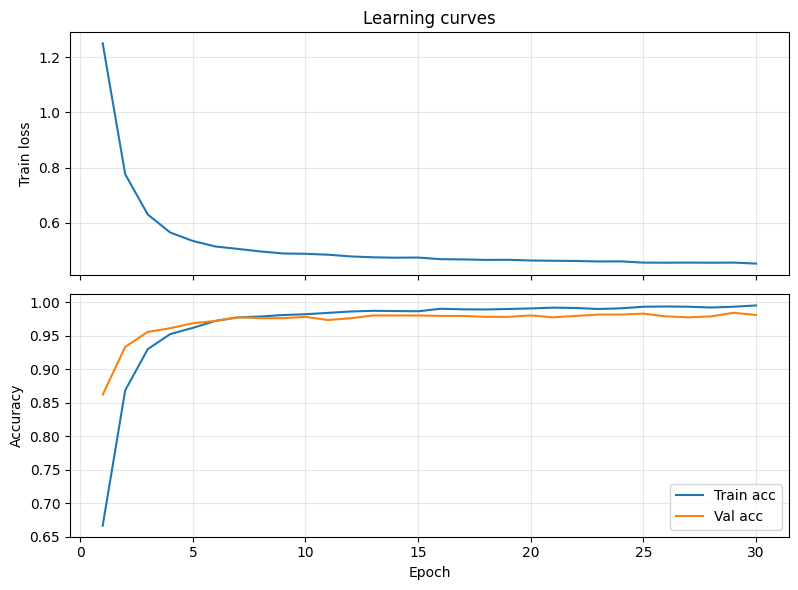

In [13]:
last_model_no_pca = data_no_PCA["models"][-1]
last_model_no_pca.plot_learning_curves()

<Figure size 800x600 with 0 Axes>

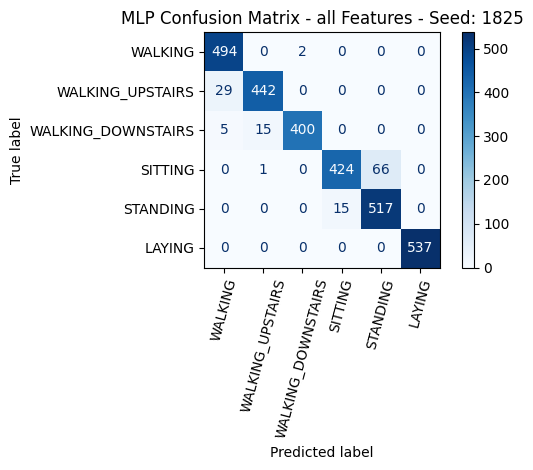

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_labels["activity_name"].tolist())
disp.plot(cmap="Blues", values_format="d")
plt.title(f"MLP Confusion Matrix - all Features - Seed: {seed}")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Custom MLP - Full Feature')

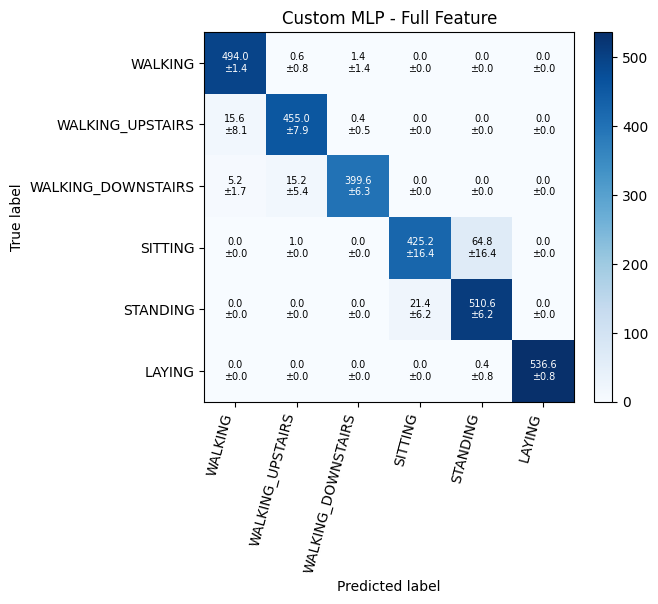

In [46]:
cms_no_PCA = np.array(cms_no_PCA)
cms_no_PCA_mean = cms_no_PCA.mean(axis=0)
cms_no_PCA_std = cms_no_PCA.std(axis=0)

fig, ax = plt.subplots()
im = ax.imshow(cms_no_PCA_mean, cmap="Blues")
labels_list = activity_labels["activity_name"].tolist()
ax.set_xticks(np.arange(len(labels_list)), labels=labels_list, rotation=75, ha="right")
ax.set_yticks(np.arange(len(labels_list)), labels=labels_list)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
for i in range(cms_no_PCA_mean.shape[0]):
    for j in range(cms_no_PCA_mean.shape[1]):
        ax.text(
            j,
            i,
            f"{cms_no_PCA_mean[i, j]:.1f}\n±{cms_no_PCA_std[i, j]:.1f}",
            ha="center",
            va="center",
            color="black" if cms_no_PCA_mean[i, j] < cms_no_PCA_mean.max() * 0.65 else "white",
            fontsize=7,
        )
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Custom MLP - Full Feature")

## PCA analysis

In [15]:
import sys

sys.path.append(os.path.abspath(".."))

In [16]:
from src.models.pca_reduction import fit_best_pca_then_transform

In [17]:
X_train_s_pca, X_test_s_pca, pca_final, meta = fit_best_pca_then_transform(X_train=X_train_s, y_train=y_train, X_test=X_test_s, random_state=RANDOM_STATE)
X_val_s_pca = pca_final.transform(X_val_s)

2026-04-12-18:06 - pca - INFO - PCA search n_components=2 val_accuracy=0.5030 variance_explained=0.5758
2026-04-12-18:06 - pca - INFO - PCA search n_components=7 val_accuracy=0.8377 variance_explained=0.6788
2026-04-12-18:06 - pca - INFO - PCA search n_components=12 val_accuracy=0.8811 variance_explained=0.7269
2026-04-12-18:06 - pca - INFO - PCA search n_components=17 val_accuracy=0.9006 variance_explained=0.7591
2026-04-12-18:06 - pca - INFO - PCA search n_components=22 val_accuracy=0.9133 variance_explained=0.7856
2026-04-12-18:06 - pca - INFO - PCA search n_components=27 val_accuracy=0.9278 variance_explained=0.8079
2026-04-12-18:06 - pca - INFO - PCA search n_components=32 val_accuracy=0.9337 variance_explained=0.8270
2026-04-12-18:06 - pca - INFO - PCA search n_components=37 val_accuracy=0.9320 variance_explained=0.8435
2026-04-12-18:06 - pca - INFO - PCA search n_components=42 val_accuracy=0.9380 variance_explained=0.8574
2026-04-12-18:06 - pca - INFO - PCA search n_components=4

In [18]:
X_train_t_pca = torch.tensor(X_train_s_pca, dtype=torch.float32)
y_train_t_pca = torch.tensor(y_train, dtype=torch.long)

X_val_t_pca = torch.tensor(X_val_s_pca, dtype=torch.float32)
y_val_t_pca = torch.tensor(y_val, dtype=torch.long)

X_test_t_pca = torch.tensor(X_test_s_pca, dtype=torch.float32)
y_test_t_pca = torch.tensor(y_test_enc, dtype=torch.long)

In [ ]:
data_PCA, cms_PCA, y_true_pca, y_pred_pca, seed_pca = MLPClassifier.run_across_seeds(
    X_train_t_pca,
    y_train_t_pca,
    X_val_t_pca,
    y_val_t_pca,
    X_test_t_pca,
    y_test_t_pca,
    input_dim=X_train_t_pca.shape[1],
    num_classes=len(torch.unique(y_train_t_pca)),
    param_grid=param_grid,
    n_seeds=5,
    random_state=RANDOM_STATE,
)


Running seed 1/1 | seed=1825
Best Params: {'size': 'large', 'lr': 0.001, 'batch_size': 32, 'epochs': 15}
Best Validation Accuracy: 0.972807613868117
Seed 1825 done | test_acc=0.9209, precision=0.9239, recall=0.9183, f1=0.9196

Average metrics across seeds:
val_acc      0.972808
test_acc     0.920937
precision    0.923876
recall       0.918324
f1           0.919630
dtype: float64

Std metrics across seeds:
val_acc     NaN
test_acc    NaN
precision   NaN
recall      NaN
f1          NaN
dtype: float64


## Learning curves (PCA)

Same as above for the PCA pipeline (last seed’s final model).

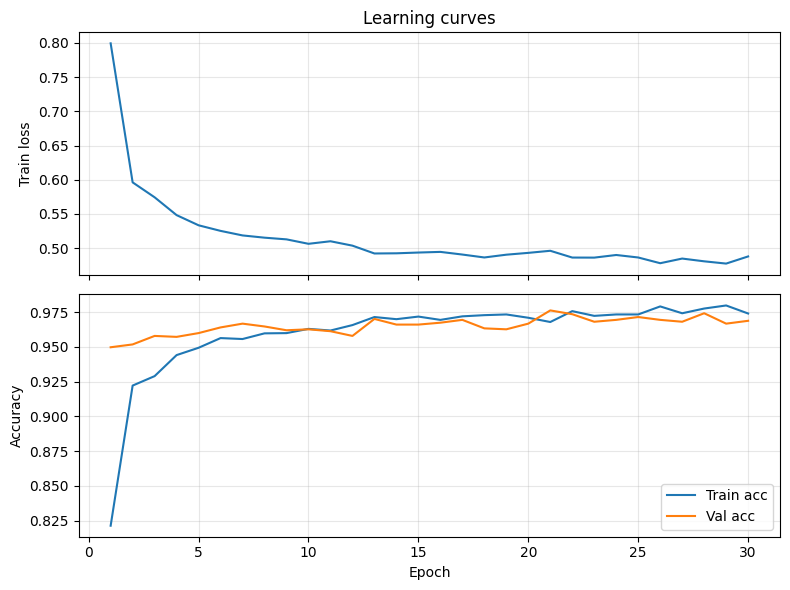

In [20]:
last_model_pca = data_PCA["models"][-1]
last_model_pca.plot_learning_curves()

<Figure size 800x600 with 0 Axes>

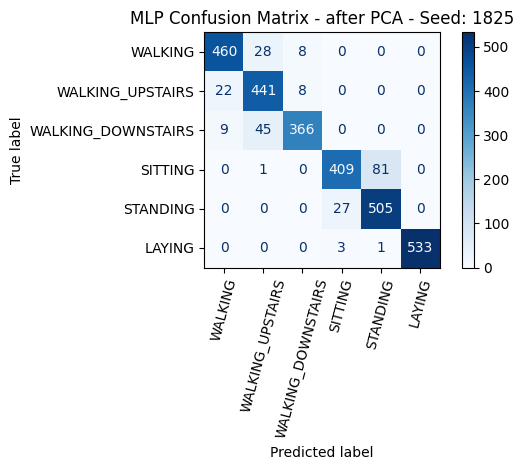

In [22]:
cm_pca = confusion_matrix(y_true_pca, y_pred_pca)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=target_names)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"MLP Confusion Matrix - after PCA - Seed: {seed_pca}")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Custom MLP - PCA')

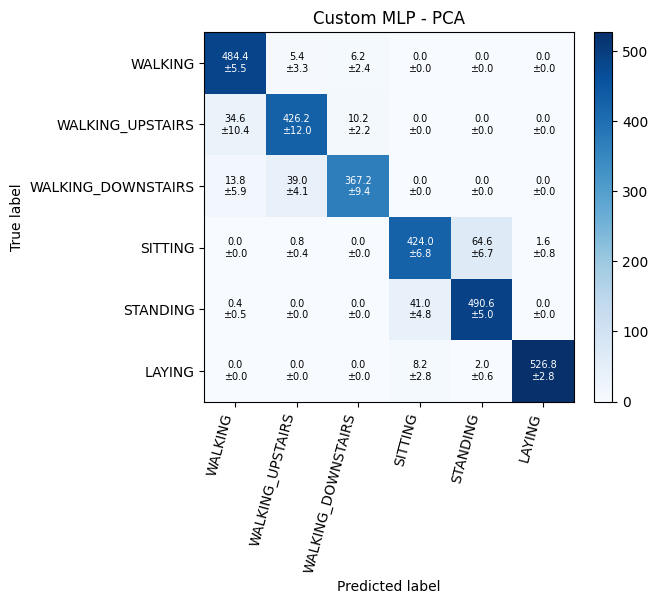

In [53]:
cms_PCA = np.array(cms_PCA)
cms_PCA_mean = cms_PCA.mean(axis=0)
cms_PCA_std = cms_PCA.std(axis=0)

fig, ax = plt.subplots()
im = ax.imshow(cms_PCA_mean, cmap="Blues")
ax.set_xticks(np.arange(len(labels_list)), labels=labels_list, rotation=75, ha="right")
ax.set_yticks(np.arange(len(labels_list)), labels=labels_list)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
for i in range(cms_PCA_mean.shape[0]):
    for j in range(cms_PCA_mean.shape[1]):
        ax.text(
            j,
            i,
            f"{cms_PCA_mean[i, j]:.1f}\n±{cms_PCA_std[i, j]:.1f}",
            ha="center",
            va="center",
            color="black" if cms_PCA_mean[i, j] < cms_PCA_mean.max() * 0.65 else "white",
            fontsize=7,
        )
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Custom MLP - PCA")

# Results

Two versions of the data were tested: one without PCA and one with PCA. Both versions were tested using the same parameter grid.

The No-PCA model achieved the stronger overall performance, with an average F1-score of 0.957320.

The PCA model also performed well, but slightly worse than the No-PCA version, with a approximate 4.0% difference between their F1-scores. It achieved an F1-score of 0.921454.

The standard deviation for the metrics across different seeds for both the no PCA and PCA models is around 0.005, indicating that our results are consistent across runs. The example confusion matrices show that both models had difficulty distinguishing between sitting and standing. The PCA model was also slightly worse at distinguishing between walking and walking upstairs, which resulted in a lower F1-score. The reason both models performed poorly at distinguishing between sitting and standing is that the two activities are relatively similar.

